In [19]:

import pandas as pd, numpy as np, torch
from sklearn.metrics import r2_score, mean_absolute_error
from benchmark_prep import build_table, split_scale, add_gdelt, log_result

ImportError: cannot import name 'log_result' from 'benchmark_prep' (/home/hefouzinho/electronic_prods_pred/benchmark_prep.py)

helper functions : with just plain concatenation for GDELT data

In [1]:
# ============================================================
# SHARED PREP — identical features/split for GAT, GCN, RF
# ============================================================
import pandas as pd, numpy as np, torch
from sklearn.preprocessing import MinMaxScaler
import os, csv
from datetime import datetime
from sklearn.metrics import r2_score, mean_absolute_error

cy = pd.read_parquet("gdelt_features_by_country_year.parquet")
GDELT_COLS = ["events_total","score_mean","score_max","score_vol",
              "goldstein_wmean","tone_mean","active_months"]

def add_gdelt(agg):
    out = agg.merge(cy[["reporterCode","year"]+GDELT_COLS],
                    left_on=["reporterCode","refYear"],
                    right_on=["reporterCode","year"], how="left")
    out[GDELT_COLS] = out[GDELT_COLS].fillna(0)
    return out.drop(columns=["year"])

def build_table(df, use_gdelt=True):
    """df = chip trade rows. Returns agg_features with/without GDELT."""
    df = df.copy()
    for c in ["refYear","primaryValue","dist","gdpcap_d","gdpcap_o","pop_o","pop_d","cmdCode","reporterCode","partnerCode"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    agg = (df.groupby(["refYear","reporterCode","cmdCode"])
             .agg(primaryValue=("primaryValue","mean"),
                  dist=("dist","first"),
                  gdpcap_d=("gdpcap_d","sum"), gdpcap_o=("gdpcap_o","sum"),
                  pop_o=("pop_o","sum"), pop_d=("pop_d","sum"))
             .reset_index())
    base = ["refYear","cmdCode","dist","gdpcap_d","gdpcap_o","pop_o","pop_d"]
    if use_gdelt:
        agg = add_gdelt(agg)
        feat_cols = base + GDELT_COLS
    else:
        feat_cols = base
    return agg, feat_cols

def split_scale(agg, feat_cols):
    agg = agg.copy()
    agg["refYear"] = pd.to_numeric(agg["refYear"], errors="coerce")
    tr, te = agg[agg.refYear <= 2022], agg[agg.refYear == 2023]
    sx, sy = MinMaxScaler(), MinMaxScaler()
    Xtr = sx.fit_transform(tr[feat_cols]);  Xte = sx.transform(te[feat_cols])
    ytr = sy.fit_transform(tr[["primaryValue"]]); yte = sy.transform(te[["primaryValue"]])
    return Xtr, Xte, ytr, yte, tr, te, sy

RESULTS_FILE = "results.csv"

def log_result(model, fusion, scoring, gdelt, risk_level, tranche, r2, mae, smape, n, notes=""):
    import os, csv
    from datetime import datetime
    RESULTS_FILE = "results.csv"
    row = {"timestamp": datetime.now().isoformat(timespec="seconds"),
           "model": model, "fusion": fusion, "scoring": scoring, "gdelt": gdelt,
           "risk_level": risk_level, "tranche": tranche,
           "r2": round(float(r2),4), "mae": round(float(mae),2),
           "smape": round(float(smape),2), "n": int(n), "notes": notes}
    new = not os.path.exists(RESULTS_FILE)
    with open(RESULTS_FILE, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if new: w.writeheader()
        w.writerow(row)
    return row

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
from benchmark_prep import log_result

def _smape(yt, yp):
    d = (np.abs(yt) + np.abs(yp)) / 2
    m = d > 0
    return np.mean(np.abs(yt[m]-yp[m])/d[m])*100 if m.sum() else np.nan

def run_rf(df, use_gdelt, scoring):
    agg, feat_cols = build_table(df, use_gdelt)
    Xtr, Xte, ytr, yte, tr, te, sy = split_scale(agg, feat_cols)
    rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0)
    rf.fit(Xtr, ytr.ravel())
    y_pred = sy.inverse_transform(rf.predict(Xte).reshape(-1,1))
    y_true = sy.inverse_transform(yte)
    yt, yp = y_true.flatten(), y_pred.flatten()

    fusion  = "concat" if use_gdelt else "none"
    scoring = scoring   if use_gdelt else "none"
    print(f"\n=== RF gdelt={use_gdelt} scoring={scoring} — Test 2023 ===")
    for label, thr in [("all",None),("1M",1e6),("10M",1e7),("100M",1e8)]:
        m = np.ones_like(yt,bool) if thr is None else (yt>=thr)
        if m.sum() < 10:
            continue
        r2, mae, sm, n = r2_score(yt[m],yp[m]), mean_absolute_error(yt[m],yp[m]), _smape(yt[m],yp[m]), int(m.sum())
        print(f"  {label:4s} | n={n:>6,} | R2={r2:.4f} | SMAPE={sm:.2f}%")
        log_result("RF", fusion, scoring, use_gdelt, "node", label, r2, mae, sm, n)
    return rf

In [5]:
import benchmark_prep as bp
df = pd.read_parquet("chips.parquet")

# 1) no GDELT
run_rf(df, use_gdelt=False, scoring="none")

# 2) concat keep-all
bp.GDELT_FILE = "gdelt_features_by_country_year.parquet"
run_rf(df, use_gdelt=True, scoring="keepall")

# 3) concat top-k
bp.GDELT_FILE = "gdelt_features_topk.parquet"
run_rf(df, use_gdelt=True, scoring="topk")

TypeError: run_rf() got an unexpected keyword argument 'scoring'

## Random Forest :

In [12]:
#null values
agg, feat_cols = build_table(df, use_gdelt=True)
print("rows:", len(agg))
print(agg[feat_cols].isna().sum())          # NaNs per feature column
print("rows with any NaN:", agg[feat_cols].isna().any(axis=1).sum())

rows: 8013
refYear              0
cmdCode              0
dist               167
gdpcap_d             0
gdpcap_o             0
pop_o                0
pop_d                0
events_total         0
score_mean           0
score_max            0
score_vol            0
goldstein_wmean      0
tone_mean            0
active_months        0
dtype: int64
rows with any NaN: 167


In [13]:
from sklearn.ensemble import RandomForestRegressor

def run_rf(df, use_gdelt=True):
    agg, feat_cols = build_table(df, use_gdelt)
    Xtr, Xte, ytr, yte, *_ = split_scale(agg, feat_cols)
    rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0)
    rf.fit(Xtr, ytr.ravel())
    pred = rf.predict(Xte)
    print(f"RF  gdelt={use_gdelt}  R2={r2_score(yte,pred):.3f}  MAE={mean_absolute_error(yte,pred):.3f}")
    return rf

In [14]:
import pandas as pd
df = pd.read_parquet("chips.parquet")

# baseline: gravity only
rf_plain = run_rf(df, use_gdelt=False)
# + geopolitics
rf_gdelt = run_rf(df, use_gdelt=True)

RF  gdelt=False  R2=0.791  MAE=0.004
RF  gdelt=True  R2=0.788  MAE=0.004


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def _smape(yt, yp):
    d = (np.abs(yt) + np.abs(yp)) / 2
    m = d > 0
    return np.mean(np.abs(yt[m] - yp[m]) / d[m]) * 100 if m.sum() else np.nan

def _tranche_report(y_true, y_pred, name):
    yt, yp = y_true.flatten(), y_pred.flatten()
    for label, thr in [("all flows", None), (">=1M", 1e6), (">=10M", 1e7), (">=100M", 1e8)]:
        m = np.ones_like(yt, bool) if thr is None else (yt >= thr)
        if m.sum() < 10:
            continue
        print(f"{name:22s} {label:10s} | n={m.sum():>7,} | "
              f"R2={r2_score(yt[m],yp[m]):.4f} | MAE={mean_absolute_error(yt[m],yp[m]):>14,.0f} | "
              f"SMAPE={_smape(yt[m],yp[m]):.2f}%")

def run_rf(df, use_gdelt=True):
    agg, feat_cols = build_table(df, use_gdelt)
    Xtr, Xte, ytr, yte, tr, te, sy = split_scale(agg, feat_cols)
    rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0)
    rf.fit(Xtr, ytr.ravel())
    pred = rf.predict(Xte).reshape(-1, 1)
    # back to real USD so it's comparable to the GAT
    y_pred = sy.inverse_transform(pred)
    y_true = sy.inverse_transform(yte)
    print(f"\n=== RF (gdelt={use_gdelt}) — Test 2023 ===")
    _tranche_report(y_true, y_pred, f"RF gdelt={use_gdelt}")
    return rf, y_true, y_pred

In [16]:
df = pd.read_parquet("chips.parquet")
rf_plain, *_ = run_rf(df, use_gdelt=False)
rf_gdelt, *_ = run_rf(df, use_gdelt=True)


=== RF (gdelt=False) — Test 2023 ===
RF gdelt=False         all flows  | n=    953 | R2=0.7908 | MAE=     6,311,730 | SMAPE=129.03%
RF gdelt=False         >=1M       | n=    208 | R2=0.7798 | MAE=    22,696,845 | SMAPE=71.58%
RF gdelt=False         >=10M      | n=     82 | R2=0.7866 | MAE=    41,194,768 | SMAPE=55.53%
RF gdelt=False         >=100M     | n=     20 | R2=0.5717 | MAE=    99,439,017 | SMAPE=40.32%

=== RF (gdelt=True) — Test 2023 ===
RF gdelt=True          all flows  | n=    953 | R2=0.7883 | MAE=     6,159,836 | SMAPE=129.78%
RF gdelt=True          >=1M       | n=    208 | R2=0.7707 | MAE=    23,045,395 | SMAPE=76.14%
RF gdelt=True          >=10M      | n=     82 | R2=0.7829 | MAE=    41,189,502 | SMAPE=58.11%
RF gdelt=True          >=100M     | n=     20 | R2=0.6750 | MAE=    89,264,718 | SMAPE=36.16%


## GCN

LOADING DATA
Train data (2017-2022): 230,095
Test 2023: 34,721
Years in train: [2017, 2018, 2019, 2020, 2021, 2022]

Train size: 184,025
Validation size: 46,070

Graph: 6811 nodes, 190836 edges

TRAINING (2017-2022)
Epoch  10/100 | Loss: 0.006431
Epoch  20/100 | Loss: 0.003148
Epoch  30/100 | Loss: 0.002299
Epoch  40/100 | Loss: 0.001855
Epoch  50/100 | Loss: 0.001755
Epoch  60/100 | Loss: 0.001637
Epoch  70/100 | Loss: 0.001600
Epoch  80/100 | Loss: 0.001571
Epoch  90/100 | Loss: 0.001553
Epoch 100/100 | Loss: 0.001538

✓ Training complete!


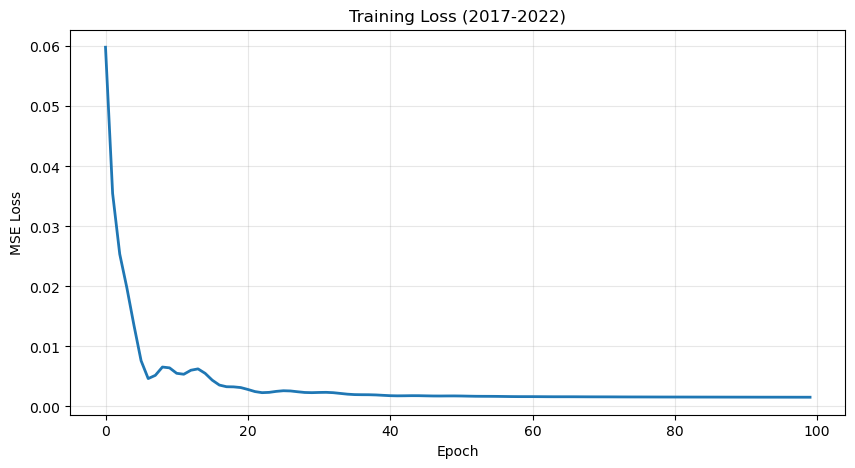


EVALUATION: Validation (2017-2022)
Original size: 46,070, After filtering unknown countries: 42,732
Validation (2017-2022) (all flows)                         | n=     5,308 | R²=-0.0010 | SMAPE=182.29%
Validation (2017-2022) (>= 1,000,000 USD, 25.4%)           | n=     1,347 | R²=-0.0235 | SMAPE=142.62%
Validation (2017-2022) (>= 10,000,000 USD, 10.3%)          | n=       548 | R²=-0.0765 | SMAPE=131.34%
Validation (2017-2022) (>= 100,000,000 USD, 2.8%)          | n=       149 | R²=-0.2940 | SMAPE=171.15%

EVALUATION: Test 2023
Original size: 34,721, After filtering unknown countries: 32,064
Test 2023            (all flows)                         | n=       948 | R²=0.0108 | SMAPE=184.36%
Test 2023            (>= 1,000,000 USD, 23.6%)           | n=       224 | R²=0.1830 | SMAPE=140.72%
Test 2023            (>= 10,000,000 USD, 9.2%)           | n=        87 | R²=0.0873 | SMAPE=101.30%
Test 2023            (>= 100,000,000 USD, 2.3%)          | n=        22 | R²=-1.1862 | SMAPE=91.93%

In [17]:
import pandas as pd
import torch
import torch.nn as nn
import dgl
from dgl.nn import GraphConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ==============================================================
# FUNCTIONS
# ==============================================================
def calculate_smape(y_true, y_pred):
    """Calcule SMAPE (0-200%, plus bas = meilleur)"""
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(numerator[mask] / denominator[mask]) * 100

def evaluate_metrics(y_true, y_pred, threshold=None, dataset_name="Dataset"):
    """Évaluer les métriques avec seuil optionnel"""
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    if threshold is not None:
        mask = y_true_flat >= threshold
        if mask.sum() < 10:
            print(f"⚠️ Pas assez de données >= {threshold:,}")
            return None
        y_true_flat = y_true_flat[mask]
        y_pred_flat = y_pred_flat[mask]
        n_total = len(y_true.flatten())
        pct = len(y_true_flat) / n_total * 100
        scope = f"(>= {threshold:,} USD, {pct:.1f}%)"
    else:
        scope = "(all flows)"

    mse = mean_squared_error(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)
    smape = calculate_smape(y_true_flat, y_pred_flat)

    print(f"{dataset_name:20s} {scope:35s} | n={len(y_true_flat):>10,} | R²={r2:.4f} | SMAPE={smape:.2f}%")

    return {'mse': mse, 'mae': mae, 'r2': r2, 'smape': smape, 'n': len(y_true_flat)}

def evaluate_dataset(model, df_eval, train_agg_features, country_code_map, scaler_features, scaler_target, batch_size, dataset_name):
    """Évaluer le modèle sur un dataset spécifique"""

    print(f"\n{'='*120}")
    print(f"EVALUATION: {dataset_name}")
    print(f"{'='*120}")

    df_eval = df_eval.copy()

    for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
        df_eval[col].fillna(df_eval[col].mean() if df_eval[col].mean() == df_eval[col].mean() else 0, inplace=True)

    df_eval['nodeID'] = df_eval['reporterCode'].map(country_code_map)
    df_eval['partnerNodeID'] = df_eval['partnerCode'].map(country_code_map)

    df_eval_filtered = df_eval.dropna(subset=['nodeID', 'partnerNodeID']).copy()
    df_eval_filtered['nodeID'] = df_eval_filtered['nodeID'].astype(int)
    df_eval_filtered['partnerNodeID'] = df_eval_filtered['partnerNodeID'].astype(int)

    print(f"Original size: {len(df_eval):,}, After filtering unknown countries: {len(df_eval_filtered):,}")

    if len(df_eval_filtered) == 0:
        print(f"⚠️ Pas de données pour {dataset_name}")
        return None, None, None

    agg_features_eval = df_eval_filtered.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
        'primaryValue': 'mean',
        'dist': 'first',
        'gdpcap_d': 'sum',
        'gdpcap_o': 'sum',
        'pop_d': 'sum',
        'pop_o': 'sum'
    }).reset_index()

    eval_country_map = {code: i for i, code in enumerate(agg_features_eval['reporterCode'])}

    features_eval = agg_features_eval[[ 'refYear', 'cmdCode', 'dist', 'gdpcap_d', 'gdpcap_o', 'pop_o', 'pop_d']]
    normalized_features_eval = scaler_features.transform(features_eval)
    normalized_target_eval = scaler_target.transform(agg_features_eval[['primaryValue']])

    df_eval_filtered['evalNodeID'] = df_eval_filtered['reporterCode'].map(eval_country_map)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['partnerCode'].map(eval_country_map)
    df_eval_filtered = df_eval_filtered.dropna(subset=['evalNodeID', 'evalPartnerID'])
    df_eval_filtered['evalNodeID'] = df_eval_filtered['evalNodeID'].astype(int)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['evalPartnerID'].astype(int)

    eval_g = dgl.graph((df_eval_filtered['evalNodeID'].to_numpy(),
                        df_eval_filtered['evalPartnerID'].to_numpy()))

    eval_feat_tensor = torch.tensor(normalized_features_eval, dtype=torch.float32)
    eval_g.ndata['feat'] = eval_feat_tensor
    eval_g = dgl.add_self_loop(eval_g)

    model.eval()
    predictions = []
    num_nodes_eval = eval_g.num_nodes()

    for i in range(0, num_nodes_eval, batch_size):
        batch_nodes = list(range(i, min(i + batch_size, num_nodes_eval)))
        batch_graph = eval_g.subgraph(batch_nodes)

        with torch.no_grad():
            logits = model(batch_graph, batch_graph.ndata['feat'])
            predictions.append(logits.unsqueeze(1))

    predictions = torch.cat(predictions, dim=0)
    predictions_np = predictions.view(predictions.size(0), -1).numpy()

    y_pred = scaler_target.inverse_transform(predictions_np)
    y_true = scaler_target.inverse_transform(normalized_target_eval)

    results = {}
    results['all'] = evaluate_metrics(y_true, y_pred, threshold=None, dataset_name=dataset_name)
    results['gte_1M'] = evaluate_metrics(y_true, y_pred, threshold=1_000_000, dataset_name=dataset_name)
    results['gte_10M'] = evaluate_metrics(y_true, y_pred, threshold=10_000_000, dataset_name=dataset_name)
    results['gte_100M'] = evaluate_metrics(y_true, y_pred, threshold=100_000_000, dataset_name=dataset_name)

    return results, y_true, y_pred

# ==============================================================
# DATA LOADING
# ==============================================================
print("="*60)
print("LOADING DATA")
print("="*60)

##source
df = pd.read_parquet("chips.parquet")

# getting numeric values
for c in ['gdp_o','gdp_d','gdpcap_o','gdpcap_d','dist','pop_o','pop_d','primaryValue','refYear','cmdCode','reporterCode','partnerCode']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['gdpcap_o'] = df['gdpcap_o'] / 1_000_000
df['gdp_o']    = df['gdp_o'] / 1_000_000
df['gdp_d']    = df['gdp_d'] / 1_000_000
df['gdpcap_d'] = df['gdpcap_d'] / 1_000_000
df['dist']     = df['dist'] / 1_000

df = df[df['cmdCode'] != 'TOTAL']
df = df[df['cmdCode'].astype(str).str.isdigit()]
df['cmdCode'] = df['cmdCode'].astype(int)
#df = df[df['cmdCode'] > 99999]

data_all = df[['refYear', 'reporterCode', 'partnerCode', 'cmdCode', 'gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist', 'primaryValue']]
data_all = data_all.drop_duplicates(['refYear', 'reporterCode', 'partnerCode', 'cmdCode'], keep='first').reset_index(drop=True)

# ==============================================================
# SPLIT PAR ANNÉE: Train 2017-2022, Test 2023
# ==============================================================
data_train_full = data_all[data_all['refYear'].isin([2017, 2018, 2019, 2020, 2021, 2022])].copy()
data_2023 = data_all[data_all['refYear'] == 2023].copy()

print(f"Train data (2017-2022): {data_train_full.shape[0]:,}")
print(f"Test 2023: {data_2023.shape[0]:,}")
print(f"Years in train: {sorted(data_train_full['refYear'].unique())}")

# Handle missing values
for col in ['gdpcap_o', 'pop_o']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'reporterCode'])[col].transform(lambda x: x.fillna(x.mean()))
for col in ['gdpcap_d', 'pop_d']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'partnerCode'])[col].transform(lambda x: x.fillna(x.mean()))
data_train_full['dist'] = data_train_full.groupby(['refYear', 'reporterCode', 'partnerCode'])['dist'].transform(lambda x: x.fillna(x.mean()))

for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
    data_train_full[col].fillna(data_train_full[col].mean(), inplace=True)

# ==============================================================
# TRAIN/VAL SPLIT (80/20)
# ==============================================================
grouped_data = data_train_full.groupby('reporterCode')
train_data = pd.DataFrame()
val_data = pd.DataFrame()

for name, group in grouped_data:
    if len(group) < 5:                 # too few rows to split — put them all in train
        train_data = pd.concat([train_data, group])
        continue
    train_group, val_group = train_test_split(group, test_size=0.2, random_state=42)
    train_data = pd.concat([train_data, train_group])
    val_data = pd.concat([val_data, val_group])

print(f"\nTrain size: {train_data.shape[0]:,}")
print(f"Validation size: {val_data.shape[0]:,}")

# ==============================================================
# FEATURE ENGINEERING
# ==============================================================
agg_features = train_data.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
    'primaryValue': 'mean',
    'dist': 'first',
    'gdpcap_d': 'sum',
    'gdpcap_o': 'sum',
    'pop_d': 'sum',
    'pop_o': 'sum'
}).reset_index()

country_code_map = {code: i for i, code in enumerate(agg_features['reporterCode'])}

train_data = train_data.copy()
train_data.loc[:, 'nodeID'] = train_data['reporterCode'].map(country_code_map)

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_to_normalize = agg_features[[ 'refYear', 'cmdCode', 'dist', 'gdpcap_d', 'gdpcap_o', 'pop_o', 'pop_d']]
normalized_features = scaler_features.fit_transform(features_to_normalize)
normalized_target = scaler_target.fit_transform(agg_features[['primaryValue']])

# ==============================================================
# CREATE GRAPH
# ==============================================================
g = dgl.graph((train_data['nodeID'].to_numpy(), train_data['partnerCode'].map(country_code_map).to_numpy()))
feat_tensor = torch.tensor(normalized_features, dtype=torch.float32)
g.ndata['feat'] = feat_tensor
g = dgl.add_self_loop(g)

print(f"\nGraph: {g.num_nodes()} nodes, {g.num_edges()} edges")

# ==============================================================
# MODEL
# ==============================================================
class GCNRegressionModel(nn.Module):
    def __init__(self, in_feats, hidden_feats):
        super(GCNRegressionModel, self).__init__()
        self.conv1 = GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = GraphConv(hidden_feats, 1, allow_zero_in_degree=True)

    def forward(self, g, features):
        x = torch.relu(self.conv1(g, features))
        x = self.conv2(g, x)
        return x.squeeze(-1)

in_feats = 7
hidden_feats = 32
model = GCNRegressionModel(in_feats, hidden_feats)   # no num_heads

# ==============================================================
# TRAINING
# ==============================================================
batch_size = 10000
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
num_nodes = g.num_nodes()
num_batches = num_nodes // batch_size + (num_nodes % batch_size > 0)
num_epochs = 100

print("\n" + "="*60)
print("TRAINING (2017-2022)")
print("="*60)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for i in range(num_batches):
        batch_nodes = list(range(i * batch_size, min((i + 1) * batch_size, num_nodes)))
        batch_graph = g.subgraph(batch_nodes)

        logits = model(batch_graph, batch_graph.ndata['feat'])
        target = torch.tensor(normalized_target[batch_nodes, 0], dtype=torch.float32).view(-1, 1)

        loss = criterion(logits.view(-1, 1), target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs} | Loss: {epoch_loss:.6f}')

print("\n✓ Training complete!")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (2017-2022)')
plt.grid(True, alpha=0.3)
plt.savefig('training_loss_2017_2022.png', dpi=300)
plt.show()

# ==============================================================
# EVALUATION: VALIDATION (2017-2022, 20%)
# ==============================================================
results_val, y_true_val, y_pred_val = evaluate_dataset(
    model, val_data, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Validation (2017-2022)"
)

# ==============================================================
# EVALUATION: TEST 2023
# ==============================================================
results_2023, y_true_2023, y_pred_2023 = evaluate_dataset(
    model, data_2023, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Test 2023"
)

# ==============================================================
# DIAGNOSTIC PAR TRANCHE
# ==============================================================
print("\n" + "="*120)
print("DIAGNOSTIC PAR TRANCHE DE VALEURS (Validation 2017-2022)")
print("="*120)

if y_true_val is not None:
    y_true_flat = y_true_val.flatten()
    y_pred_flat = y_pred_val.flatten()

    tranches = [
        ('< 100K USD', y_true_flat < 100_000),
        ('100K - 1M USD', (y_true_flat >= 100_000) & (y_true_flat < 1_000_000)),
        ('1M - 10M USD', (y_true_flat >= 1_000_000) & (y_true_flat < 10_000_000)),
        ('10M - 100M USD', (y_true_flat >= 10_000_000) & (y_true_flat < 100_000_000)),
        ('> 100M USD', y_true_flat >= 100_000_000)
    ]

    for nom, mask in tranches:
        if mask.sum() > 1:
            r2_t = r2_score(y_true_flat[mask], y_pred_flat[mask])
            smape_t = calculate_smape(y_true_flat[mask], y_pred_flat[mask])
            print(f"{nom:25s} | n={mask.sum():>10,} | R²={r2_t:>8.4f} | SMAPE={smape_t:>6.2f}%")

# ==============================================================
# SUMMARY TABLE
# ==============================================================
print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)

all_results = [
    ("Validation (2017-2022)", results_val),
    ("Test 2023", results_2023)
]

# Table >= 100M USD
print("\n--- Flux >= 100M USD ---")
print(f"{'Dataset':<25} | {'n':>8} | {'MSE':>15} | {'MAE':>12} | {'R²':>8} | {'SMAPE':>10}")
print("-"*90)

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name:<25} | {r['n']:>8,} | {r['mse']:>15,.2f} | {r['mae']:>12,.2f} | {r['r2']:>8.4f} | {r['smape']:>9.2f}%")

# ==============================================================
# LATEX TABLE
# ==============================================================
print("\n" + "="*100)
print("LATEX TABLE (>= 100M USD)")
print("="*100)

print(r"""
\begin{table}[h]
\centering
\caption{GAT Model Performance for Trade Flow Prediction (trained on 2017-2022, flows $\geq$ 100M USD)}
\label{tab:results_2017_2022}
\begin{tabular}{l|r|r|r|c|c}
Dataset & n & MSE & MAE & R² & SMAPE \\
\hline""")

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name} & {r['n']:,} & {r['mse']:,.2f} & {r['mae']:,.2f} & {r['r2']:.2f} & {r['smape']:.2f}\\% \\\\")

print(r"""\end{tabular}
\end{table}
""")

# ==============================================================
# SAVE MODEL
# ==============================================================
torch.save(model.state_dict(), 'model_gcn_2017_2022_chips.pth')
print("\n✓ Model saved: model_gcn_2017_2022.pth")